In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
df = pd.read_csv(r"C:\Users\Admin\Documents\Data for MSC Thesis\eth_householdgeovariables_y5.csv")


In [50]:
df.head()

,household_id,dist_road,dist_market,dist_border,dist_popcenter,dist_admhq,af_bio_1_x,af_bio_8_x,af_bio_12_x,af_bio_13_x,...,c2_evimax_avg,c2_grn_avg,c2_sen_avg,c2_h2021_eviarea,c2_h2021_evimax,c2_h2021_grn,c2_h2021_sen,lat_dd_mod,lon_dd_mod,suppress
0,20101010100104011,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
1,20101010100104022,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
2,20101010100104033,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
3,20101010100104044,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
4,20101010100104055,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0


In [51]:
print(df.shape)

(4890, 52)


In [52]:
print(df.isnull().sum())

household_id            0
dist_road               0
dist_market             0
dist_border             0
dist_popcenter          0
dist_admhq              0
af_bio_1_x              0
af_bio_8_x              0
af_bio_12_x             0
af_bio_13_x             0
af_bio_16_x             0
afmnslp_pct             0
srtm_1k                 0
popdensity              0
cropshare               0
sq1                     0
sq2                     0
sq3                     0
sq4                     0
sq5                     0
sq6                     0
sq7                     0
ssa_aez09               0
landcov                 0
twi_ne                  0
pct_urban_cluster       0
pct_urban_center        0
h2021_tot               0
h2021_wetQstart         0
h2021_wetQ              0
anntot_avg              0
wetQ_avgstart           0
wetQ_avg                0
eviarea_avg             0
evimax_avg              0
grn_avg                 0
sen_avg                 0
h2021_eviarea           0
h2021_evimax

In [53]:
# Drop unnecessary columns
cols_to_drop = [
    "household_id",       # ID, not useful
    "suppress",           # control flag
    "af_bio_12_x",        # target variable (keep separately)
    # Columns with lots of missing values
    "c2_eviarea_avg", "c2_evimax_avg", "c2_grn_avg", "c2_sen_avg",
    "c2_h2021_eviarea", "c2_h2021_evimax", "c2_h2021_grn", "c2_h2021_sen",
    # Optional low-importance columns (can drop after feature importance check)
    "sq1", "sq2", "sq3", "sq4", "sq5", "sq6", "sq7"
]

df_clean = df.drop(columns=cols_to_drop, errors="ignore")

# Step 3: Define target and features
y = df["af_bio_12_x"]  # rainfall
X = df_clean.copy()    # all remaining columns are features

# Step 4: Fill missing values in features
X = X.fillna(X.mean(numeric_only=True))

print(" Cleaned dataset shape:", X.shape)
print("Features:", X.columns)

 Cleaned dataset shape: (4890, 34)
Features: Index(['dist_road', 'dist_market', 'dist_border', 'dist_popcenter',
       'dist_admhq', 'af_bio_1_x', 'af_bio_8_x', 'af_bio_13_x', 'af_bio_16_x',
       'afmnslp_pct', 'srtm_1k', 'popdensity', 'cropshare', 'ssa_aez09',
       'landcov', 'twi_ne', 'pct_urban_cluster', 'pct_urban_center',
       'h2021_tot', 'h2021_wetQstart', 'h2021_wetQ', 'anntot_avg',
       'wetQ_avgstart', 'wetQ_avg', 'eviarea_avg', 'evimax_avg', 'grn_avg',
       'sen_avg', 'h2021_eviarea', 'h2021_evimax', 'h2021_grn', 'h2021_sen',
       'lat_dd_mod', 'lon_dd_mod'],
      dtype='object')


In [54]:
cols_to_keep = [
    'dist_road', 'dist_market', 'dist_border', 'dist_popcenter',
    'dist_admhq', 'af_bio_1_x', 'af_bio_8_x', 'af_bio_13_x', 'af_bio_16_x',
    'afmnslp_pct', 'srtm_1k', 'popdensity', 'cropshare', 'ssa_aez09',
    'landcov', 'twi_ne', 'pct_urban_cluster', 'pct_urban_center',
    'h2021_tot', 'h2021_wetQstart', 'h2021_wetQ', 'anntot_avg',
    'wetQ_avgstart', 'wetQ_avg', 'eviarea_avg', 'evimax_avg', 'grn_avg',
    'sen_avg', 'h2021_eviarea', 'h2021_evimax', 'h2021_grn', 'h2021_sen',
    'lat_dd_mod', 'lon_dd_mod'
]

df_features = df[cols_to_keep].copy()

# Fill missing numeric values with column mean
df_features = df_features.fillna(df_features.mean(numeric_only=True))

# Fill missing categorical variables with mode (if any)
for col in df_features.select_dtypes(include='object').columns:
    df_features[col] = df_features[col].fillna(df_features[col].mode()[0])

print(" Missing values filled")
print(df_features.isnull().sum()) 

 Missing values filled
dist_road            0
dist_market          0
dist_border          0
dist_popcenter       0
dist_admhq           0
af_bio_1_x           0
af_bio_8_x           0
af_bio_13_x          0
af_bio_16_x          0
afmnslp_pct          0
srtm_1k              0
popdensity           0
cropshare            0
ssa_aez09            0
landcov              0
twi_ne               0
pct_urban_cluster    0
pct_urban_center     0
h2021_tot            0
h2021_wetQstart      0
h2021_wetQ           0
anntot_avg           0
wetQ_avgstart        0
wetQ_avg             0
eviarea_avg          0
evimax_avg           0
grn_avg              0
sen_avg              0
h2021_eviarea        0
h2021_evimax         0
h2021_grn            0
h2021_sen            0
lat_dd_mod           0
lon_dd_mod           0
dtype: int64


In [55]:

# Step 1: Add target variable as a new column
df_cleaned = df_features.copy()
df_cleaned['rainfall'] = df['af_bio_12_x']

# Step 2: Check the new dataframe
print("Combined dataset shape:", df_cleaned.shape)
print(df_cleaned.head())




Combined dataset shape: (4890, 35)
   dist_road  dist_market  dist_border  dist_popcenter  dist_admhq  \
0        7.7   162.300003    82.900002             0.4         0.0   
1        7.7   162.300003    82.900002             0.4         0.0   
2        7.7   162.300003    82.900002             0.4         0.0   
3        7.7   162.300003    82.900002             0.4         0.0   
4        7.7   162.300003    82.900002             0.4         0.0   

   af_bio_1_x  af_bio_8_x  af_bio_13_x  af_bio_16_x  afmnslp_pct  ...  \
0         283         307           47           98            2  ...   
1         283         307           47           98            2  ...   
2         283         307           47           98            2  ...   
3         283         307           47           98            2  ...   
4         283         307           47           98            2  ...   

   evimax_avg  grn_avg  sen_avg h2021_eviarea h2021_evimax  h2021_grn  \
0       0.342      187      280 

In [56]:
# Step 3: Check for duplicate rows
duplicates = df_cleaned.duplicated()

# Print number of duplicate rows
print("Number of duplicate rows:", duplicates.sum())

# Optional: view duplicate rows
print("\nDuplicate rows:")
print(df_cleaned[duplicates])


Number of duplicate rows: 4376

Duplicate rows:
      dist_road  dist_market  dist_border  dist_popcenter  dist_admhq  \
1           7.7   162.300003    82.900002             0.4         0.0   
2           7.7   162.300003    82.900002             0.4         0.0   
3           7.7   162.300003    82.900002             0.4         0.0   
4           7.7   162.300003    82.900002             0.4         0.0   
5           7.7   162.300003    82.900002             0.4         0.0   
...         ...          ...          ...             ...         ...   
4885        8.3    22.400000   183.899994            22.4         0.2   
4886        8.3    22.400000   183.899994            22.4         0.2   
4887        8.3    22.400000   183.899994            22.4         0.2   
4888        8.3    22.400000   183.899994            22.4         0.2   
4889        8.3    22.400000   183.899994            22.4         0.2   

      af_bio_1_x  af_bio_8_x  af_bio_13_x  af_bio_16_x  afmnslp_pct  ...  \

In [57]:
# Step 4: Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Check the shape after removing duplicates
print(" Dataset shape after removing duplicates:", df_cleaned.shape)

# Verify no more duplicates
print("Number of duplicates now:", df_cleaned.duplicated().sum())


 Dataset shape after removing duplicates: (514, 35)
Number of duplicates now: 0


In [58]:
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_cleaned[numeric_cols].quantile(0.25)
Q3 = df_cleaned[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Find outliers
outliers = ((df_cleaned[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df_cleaned[numeric_cols] > (Q3 + 1.5 * IQR)))

# Count outliers per column
print("Number of outliers per column:")
print(outliers.sum())

# View rows with any outlier
rows_with_outliers = df_cleaned[outliers.any(axis=1)]
print(rows_with_outliers)


Number of outliers per column:
dist_road            62
dist_market          22
dist_border           0
dist_popcenter       31
dist_admhq            2
af_bio_1_x            0
af_bio_8_x            0
af_bio_13_x           0
af_bio_16_x           0
afmnslp_pct          14
srtm_1k               0
popdensity           51
cropshare             0
twi_ne               22
pct_urban_cluster    26
pct_urban_center      0
h2021_tot            17
h2021_wetQstart       0
h2021_wetQ           44
anntot_avg            0
wetQ_avgstart         0
wetQ_avg              9
eviarea_avg           0
evimax_avg            0
grn_avg               0
sen_avg              44
h2021_eviarea         0
h2021_evimax          0
h2021_grn             0
h2021_sen            63
lat_dd_mod           27
lon_dd_mod            0
rainfall              3
dtype: int64
      dist_road  dist_market  dist_border  dist_popcenter  dist_admhq  \
14     9.300000   169.800003    75.699997        8.500000         0.0   
24     0.500000   

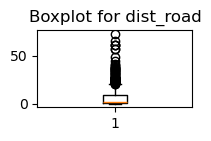

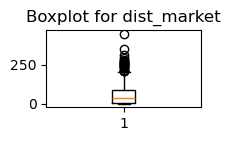

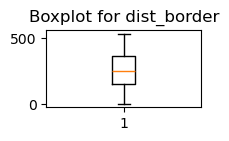

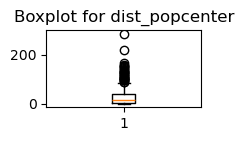

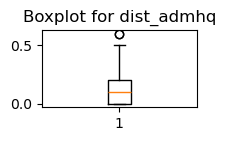

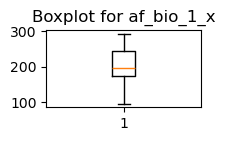

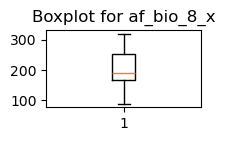

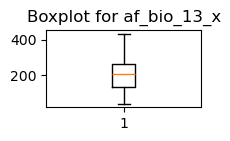

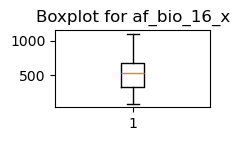

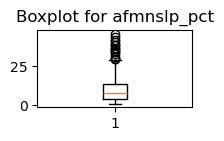

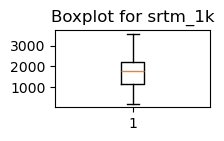

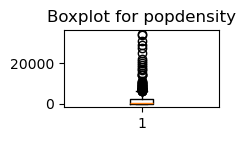

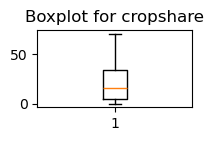

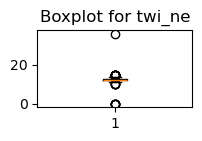

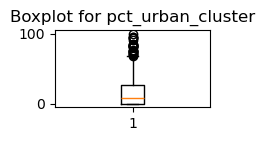

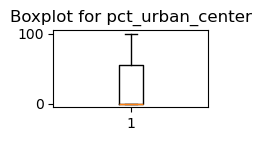

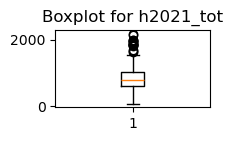

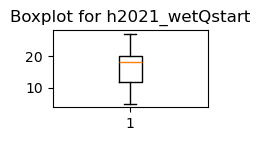

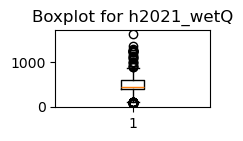

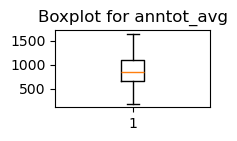

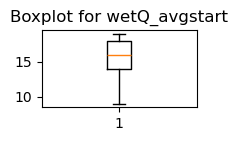

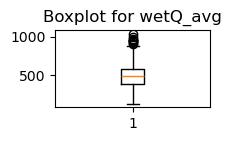

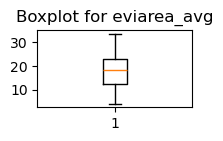

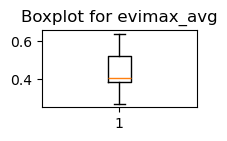

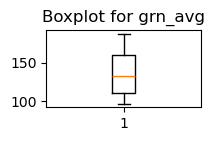

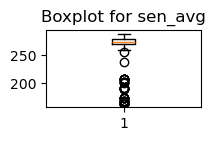

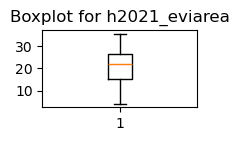

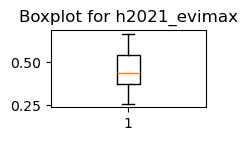

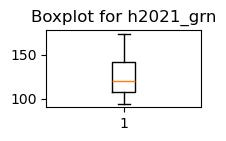

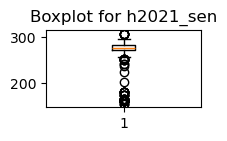

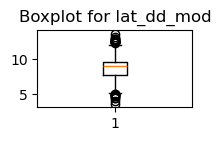

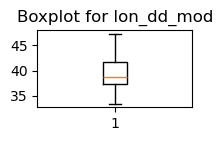

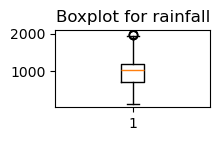

In [61]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df_cleaned.select_dtypes(include='number').columns

# Loop through each numeric column and plot boxplots
for col in numeric_cols:
    plt.figure(figsize=(2, 1))
    plt.boxplot(df_cleaned[col])
    plt.title(f'Boxplot for {col}')
    plt.show()



In [62]:
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

Q1 = df_cleaned[numeric_cols].quantile(0.25)
Q3 = df_cleaned[numeric_cols].quantile(0.75)


IQR = Q3 - Q1

# Clip each numeric column based on IQR thresholds
for col in numeric_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_cleaned[col] = df_cleaned[col].clip(lower, upper)


In [63]:
# After capping, check min and max values for numeric columns
print(df_cleaned[numeric_cols].agg(['min', 'max']))

df_cleaned.head()

     dist_road  dist_market  dist_border  dist_popcenter  dist_admhq  \
min        0.0     0.400000          3.2        0.400000         0.0   
max       21.0   209.149996        531.5       89.187498         0.5   

     af_bio_1_x  af_bio_8_x  af_bio_13_x  af_bio_16_x  afmnslp_pct  ...  \
min          95          89           37           78            1  ...   
max         293         319          433         1103           29  ...   

     evimax_avg  grn_avg  sen_avg  h2021_eviarea  h2021_evimax  h2021_grn  \
min       0.269       97    257.5          4.190         0.258         94   
max       0.641      187    289.0         35.444         0.666        174   

     h2021_sen  lat_dd_mod  lon_dd_mod  rainfall  
min      255.5    5.092198   33.434831   145.000  
max      299.5   12.333356   47.307840  1945.125  

[2 rows x 33 columns]


,dist_road,dist_market,dist_border,dist_popcenter,dist_admhq,af_bio_1_x,af_bio_8_x,af_bio_13_x,af_bio_16_x,afmnslp_pct,...,evimax_avg,grn_avg,sen_avg,h2021_eviarea,h2021_evimax,h2021_grn,h2021_sen,lat_dd_mod,lon_dd_mod,rainfall
0,7.7,162.300003,82.900002,0.400000,0.0,283,307,47,98,2,...,0.342,187,280.0,9.156000,0.343,174,275.0,11.749938,41.080363,184.0
14,9.3,169.800003,75.699997,8.500000,0.0,284,309,45,93,1,...,0.342,187,280.0,9.156000,0.343,174,275.0,11.707530,41.146505,174.0
24,0.5,209.149996,36.500000,74.900002,0.1,283,319,37,83,2,...,0.342,187,280.0,9.156000,0.343,174,275.0,12.057510,41.933473,163.0
35,1.3,194.000000,48.700001,5.600000,0.1,287,315,38,78,2,...,0.342,187,280.0,9.156000,0.343,174,275.0,11.562991,41.432114,145.0
36,0.7,9.800000,249.300003,9.800000,0.3,149,161,284,700,18,...,0.398,167,273.0,16.330999,0.408,145,274.0,11.133939,39.639801,1136.0


In [64]:

print(df_cleaned.columns.tolist())


['dist_road', 'dist_market', 'dist_border', 'dist_popcenter', 'dist_admhq', 'af_bio_1_x', 'af_bio_8_x', 'af_bio_13_x', 'af_bio_16_x', 'afmnslp_pct', 'srtm_1k', 'popdensity', 'cropshare', 'ssa_aez09', 'landcov', 'twi_ne', 'pct_urban_cluster', 'pct_urban_center', 'h2021_tot', 'h2021_wetQstart', 'h2021_wetQ', 'anntot_avg', 'wetQ_avgstart', 'wetQ_avg', 'eviarea_avg', 'evimax_avg', 'grn_avg', 'sen_avg', 'h2021_eviarea', 'h2021_evimax', 'h2021_grn', 'h2021_sen', 'lat_dd_mod', 'lon_dd_mod', 'rainfall']


In [65]:

X = df_cleaned.drop(columns=['rainfall'])
y = df_cleaned['rainfall']

# Identify categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Only encode if there are categorical columns
if cat_cols:
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_encoded = X.copy()  # No encoding needed

# Combine with target
df_encoded = X_encoded.copy()
df_encoded['rainfall'] = y

print("✅ Encoded dataset shape:", df_encoded.shape)
df_encoded.head()


Categorical columns to encode: ['ssa_aez09', 'landcov']
✅ Encoded dataset shape: (514, 47)


,dist_road,dist_market,dist_border,dist_popcenter,dist_admhq,af_bio_1_x,af_bio_8_x,af_bio_13_x,af_bio_16_x,afmnslp_pct,...,ssa_aez09_Tropic-warm/subhumid,landcov_Built-up,landcov_Closed forest deciduous broad leaf,landcov_Closed forest evergreen broad leaf,landcov_Cropland,landcov_Herbaceous vegetation,landcov_Open forest deciduous broad leaf,landcov_Open forest unknown,landcov_Shrubs,rainfall
0,7.7,162.300003,82.900002,0.400000,0.0,283,307,47,98,2,...,False,False,False,False,False,False,False,False,False,184.0
14,9.3,169.800003,75.699997,8.500000,0.0,284,309,45,93,1,...,False,False,False,False,True,False,False,False,False,174.0
24,0.5,209.149996,36.500000,74.900002,0.1,283,319,37,83,2,...,False,False,False,False,False,False,False,False,False,163.0
35,1.3,194.000000,48.700001,5.600000,0.1,287,315,38,78,2,...,False,False,False,False,True,False,False,False,False,145.0
36,0.7,9.800000,249.300003,9.800000,0.3,149,161,284,700,18,...,False,True,False,False,False,False,False,False,False,1136.0


In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop target column
X = df_encoded.drop(columns=['rainfall'])

# Ensure all columns are numeric (VIF only works for numeric)
X = X.select_dtypes(include=['number'])

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by highest VIF first
vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data.head(20)


,Feature,VIF
25,sen_avg,4843.050313
29,h2021_sen,3340.478809
6,af_bio_8_x,3023.213381
27,h2021_evimax,2927.894038
23,evimax_avg,2802.962115
5,af_bio_1_x,2659.711480
31,lon_dd_mod,2244.184024
13,twi_ne,760.674545
26,h2021_eviarea,759.569682
24,grn_avg,694.156788


In [67]:
to_drop = [
    'sen_avg', 'h2021_sen',
    'af_bio_8_x', 'h2021_evimax', 'evimax_avg',
    'af_bio_1_x', 'lon_dd_mod', 'lat_dd_mod',
    'grn_avg', 'h2021_grn', 'eviarea_avg', 'af_bio_16_x', 'af_bio_13_x', 
    'anntot_avg', 'wetQ_avg', 
    'h2021_tot', 'h2021_wetQ', 
    'wetQ_avgstart', 'twi_ne'
]

X_reduced = X.drop(columns=to_drop)


In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure numeric only
X_reduced = X_reduced.select_dtypes(include=['number'])

# Compute new VIF values
vif_data = pd.DataFrame()
vif_data["Feature"] = X_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data.head(20)


,Feature,VIF
6,srtm_1k,24.288386
7,popdensity,15.281881
10,pct_urban_center,14.248839
11,h2021_wetQstart,9.170004
2,dist_border,7.885386
12,h2021_eviarea,6.649860
8,cropshare,6.352059
5,afmnslp_pct,5.138167
3,dist_popcenter,4.755395
1,dist_market,4.292127


In [69]:

from sklearn.preprocessing import StandardScaler
# Separate features (X) and target (y)
X = df_encoded.drop('rainfall', axis=1)  # replace 'rainfall' with your target column name
y = df_encoded['rainfall']

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training features and transform
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Combine scaled features with target for final clean dataset
df_scaled = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

print("Feature scaling completed successfully!")
print("Scaled dataset shape:", df_scaled.shape)
print(df_scaled.head())



Feature scaling completed successfully!
Scaled dataset shape: (514, 47)
   dist_road  dist_market  dist_border  dist_popcenter  dist_admhq  \
0   0.267054     1.690155    -1.339374       -0.978437   -0.975216   
1   0.485348     1.812289    -1.394309       -0.676441   -0.975216   
2  -0.715268     2.453090    -1.693396        1.799178   -0.228180   
3  -0.606121     2.206377    -1.600312       -0.784563   -0.228180   
4  -0.687981    -0.793252    -0.069781       -0.627973    1.265891   

   af_bio_1_x  af_bio_8_x  af_bio_13_x  af_bio_16_x  afmnslp_pct  ...  \
0    1.804142    2.140485    -1.876844    -1.822913    -1.069695  ...   
1    1.827242    2.181956    -1.900197    -1.844561    -1.203375  ...   
2    1.804142    2.389311    -1.993607    -1.887855    -1.069695  ...   
3    1.896542    2.306369    -1.981931    -1.909503    -1.069695  ...   
4   -1.291267   -0.886910     0.890445     0.783422     1.069175  ...   

   ssa_aez09_Tropic-warm/subhumid  landcov_Built-up  \
0            

In [70]:
from sklearn.model_selection import train_test_split

# Split features and target again
X = df_scaled.drop('rainfall', axis=1)
y = df_scaled['rainfall']

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successful!")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Data split successful!
Training set shape: (411, 46)
Testing set shape: (103, 46)


In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(" Model trained successfully!")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


 Model trained successfully!
R² Score: 0.9760
MAE: 45.9006
RMSE: 65.1269


In [72]:
# Check for overfitting
y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"R² (Train): {r2_train:.4f}")
print(f"R² (Test): {r2_test:.4f}")



R² (Train): 0.9739
R² (Test): 0.9760


In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize
rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Metrics
print("R² (Train):", r2_score(y_train, rf.predict(X_train)))
print("R² (Test):", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))


R² (Train): 0.99653012992401
R² (Test): 0.9469112799557554
MAE: 50.455976941747565
RMSE: 96.92668613888253


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize Regularized Random Forest
rf = RandomForestRegressor(
    n_estimators=500,        # number of trees (increase for better stability)
    max_depth=20,            # limit tree depth to prevent overfitting
    min_samples_split=5,     # minimum samples required to split a node
    min_samples_leaf=2,      # minimum samples required in a leaf node
    max_features='sqrt',     # number of features considered at each split
    bootstrap=True,          # use bootstrap samples
    random_state=42          # for reproducibility
)

#  Train the model
rf.fit(X_train, y_train)

# Predict on test data
y_pred = rf.predict(X_test)

#  Evaluate model performance
r2_train = r2_score(y_train, rf.predict(X_train))
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

# Display results neatly
print("Model Performance Summary:")
print(f"R² (Train): {r2_train:.4f}")
print(f"R² (Test):  {r2_test:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")


Model Performance Summary:
R² (Train): 0.9907
R² (Test):  0.9660
MAE:         48.8904
RMSE:        77.5636


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'max_depth': [15, 20, 25],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(n_estimators=500, random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best MAE:", -grid.best_score_)



Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#  Final Random Forest with Best Params
rf_best = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=3,
    random_state=42
)

# Train on all training data
rf_best.fit(X_train, y_train)

# Predict
y_pred_best = rf_best.predict(X_test)

# Evaluate
r2_train = r2_score(y_train, rf_best.predict(X_train))
r2_test = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
rmse = mean_squared_error(y_test, y_pred_best, squared=False)

print("Final Model Performance:")
print(f"R² (Train): {r2_train:.4f}")
print(f"R² (Test):  {r2_test:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")
